In [1]:
# Importing necessary libraries for data preprocessing
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Importing necessary libraries for building and evaluating models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.losses import KLDivergence, MeanSquaredError

# Importing necessary libraries for saving and loading models
import joblib

In [2]:
df = pd.read_csv('KDDTrain+.txt', header=None)

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
df[41].unique()

array(['normal', 'neptune', 'warezclient', 'ipsweep', 'portsweep',
       'teardrop', 'nmap', 'satan', 'smurf', 'pod', 'back',
       'guess_passwd', 'ftp_write', 'multihop', 'rootkit',
       'buffer_overflow', 'imap', 'warezmaster', 'phf', 'land',
       'loadmodule', 'spy', 'perl'], dtype=object)

In [5]:
values = ['ftp_write', 'multihop', 'rootkit', 'imap', 'warezmaster', 'phf', 'land', 'loadmodule', 'spy', 'perl']
for value in values:
    df.drop(df[df[41] == value].index, inplace = True)
    
df[41].unique()

array(['normal', 'neptune', 'warezclient', 'ipsweep', 'portsweep',
       'teardrop', 'nmap', 'satan', 'smurf', 'pod', 'back',
       'guess_passwd', 'buffer_overflow'], dtype=object)

In [6]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove(41)

In [7]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove(42)  # removing additional info column

In [8]:
# Define preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)])

In [9]:
# Applying ColumnTransformer
df_processed = preprocessor.fit_transform(df.drop(columns=[41, 42]))
df_processed = pd.DataFrame(df_processed)

In [10]:
# Convert the target column to numeric
le = LabelEncoder()
df[41] = le.fit_transform(df[41])

In [11]:
# Extract target variable
y = df[41].values

In [12]:
# Check shape of preprocessed data
df_processed.shape, y.shape

((125881, 122), (125881,))

In [13]:
# Set random seed for reproducibility 
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
# Define the dimensionality of the bottleneck for each autoencoder
bottleneck_dims = [64, 32, 16, 8]

In [15]:
# Store the models and their encoders
autoencoders = []
encoders = []

In [16]:
weight_decay = 0.001
learning_rate = 0.007

In [17]:
# Define the sparsity parameter and target sparsity
sparsity_target = 0.05
sparsity_weight = 0.1

mse_loss = MeanSquaredError()
kl_loss = KLDivergence()

def custom_loss(y_true, y_pred):
    # Calculate the MSE loss
    mse = mse_loss(y_true, y_pred)

    # Calculate the average activation of the bottleneck layer
    avg_activation = K.mean(y_pred, axis=0)

    # Calculate the KL Divergence for the sparsity constraint
    kl = K.sum(sparsity_target * K.log(sparsity_target / avg_activation) +
               (1 - sparsity_target) * K.log((1 - sparsity_target) / (1 - avg_activation)))

    # Combine the MSE and KL Divergence losses
    return mse + sparsity_weight * kl

In [18]:
def autoencoder_model(bottleneck_dims):
    autoencoder = Sequential([
        Dense(64, activation = 'relu', input_shape=(df_processed.shape[1],)),
        Dense(bottleneck_dims, activation = 'relu'),
        Dense(df_processed.shape[1], activation = 'sigmoid')
    ])
    
    return autoencoder

# Define and train the autoencoders
for i, bottleneck_dim in enumerate(bottleneck_dims):

    print(f"Training {i+1} autoencoder model")
    # Define the autoencoder
    autoencoder = autoencoder_model(bottleneck_dim)
    
    # Compile the autoencoder
    autoencoder.compile(optimizer = Adam(learning_rate = learning_rate, decay = weight_decay), loss = custom_loss)
    
    # Train the autoencoder
    history = autoencoder.fit(df_processed, df_processed, epochs = 10, batch_size = 256, verbose = 1)
    
    # Define the encoder
    encoder = Sequential(autoencoder.layers[:2])
    
    # Save the autoencoder and encoder
    autoencoders.append(autoencoder)
    encoders.append(encoder)
    
    # Update df_processed for the next autoencoder
    df_processed = encoder.predict(df_processed)
    print("\n")

Training 1 autoencoder model
Epoch 1/10
492/492 [==============================] - 5s 5ms/step - loss: 0.1316
Epoch 2/10
492/492 [==============================] - 2s 5ms/step - loss: 0.0520
Epoch 3/10
492/492 [==============================] - 2s 4ms/step - loss: 0.0496
Epoch 4/10
492/492 [==============================] - 2s 4ms/step - loss: 0.0483
Epoch 5/10
492/492 [==============================] - 3s 5ms/step - loss: 0.0476
Epoch 6/10
492/492 [==============================] - 2s 5ms/step - loss: 0.0469
Epoch 7/10
492/492 [==============================] - 2s 4ms/step - loss: 0.0466
Epoch 8/10
492/492 [==============================] - 2s 4ms/step - loss: 0.0465
Epoch 9/10
492/492 [==============================] - 3s 5ms/step - loss: 0.0462
Epoch 10/10
492/492 [==============================] - 2s 5ms/step - loss: 0.0461


Training 2 autoencoder model
Epoch 1/10
492/492 [==============================] - 3s 3ms/step - loss: 1.0195A: 0s - loss: 1.021
Epoch 2/10
492/492 [=========

In [19]:
df_processed = pd.DataFrame(df_processed)
df_processed

,0,1,2,3,4,5,6,7
0,1.221105,39.256081,54.998268,42.811520,0.0,58.175461,0.000000,30.541443
1,0.000000,87.600784,129.038101,124.573067,0.0,17.520706,3.156309,69.424438
2,0.000000,37.536438,37.045055,0.000000,0.0,29.524042,5.310134,0.000000
3,16.946180,0.000000,0.022169,2.159098,0.0,1.676496,0.000000,42.800713
4,17.472408,0.000000,0.000000,1.753002,0.0,0.000000,0.000000,45.685268
...,...,...,...,...,...,...,...,...
125876,0.000000,37.512413,37.200142,0.000000,0.0,29.494953,5.504900,0.000000
125877,0.000000,69.370903,60.757603,68.835770,0.0,0.000000,0.000000,52.028656
125878,27.377996,12.060703,25.365484,1.497818,0.0,36.432774,0.000000,40.121277
125879,0.317264,15.547242,37.744476,0.000000,0.0,12.835283,24.167080,3.532213


In [20]:
# Now, df_processed is the output from the last encoder. We can use this to train our XGBoost model.
X_train, X_test, y_train, y_test = train_test_split(df_processed, y, test_size=0.2, random_state=42)

***

In [21]:
# Hyperparameter tuning for XGBM Classifier using GridSearchCV

param_grid = {
    'max_depth': [6, 8, 10],
    'learning_rate': [0.1, 0.3],
    'n_estimators': [100, 200, 300],
    'subsample': [0.5, 0.8, 1.0]
}

print(param_grid)

{'max_depth': [6, 8, 10], 'learning_rate': [0.1, 0.3], 'n_estimators': [100, 200, 300], 'subsample': [0.5, 0.8, 1.0]}


In [22]:
# Intialize the XGBoost model 
xgboost = XGBClassifier(objective = 'multi:softmax', eval_metric = 'mlogloss', num_classes = 13)

# Perform grid search with cross-validation
xgboost_gridcv = GridSearchCV(estimator = xgboost ,param_grid = param_grid, cv=3, verbose=3, n_jobs = -1)

### fit the grid searched model
%time xgboost_gridcv.fit(X_train,y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[12:06:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "num_classes" } are not used.

Wall time: 2h 55min 38s


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                   

In [23]:
# save the model to a file
joblib.dump(xgboost_gridcv, 'xgboost_gridseachcv_thirteen.joblib')

['xgboost_gridseachcv_thirteen.joblib']

In [24]:
# print best parameter after tuning 
print(xgboost_gridcv.best_params_) 

# Get the best estimator
best_gridcv = xgboost_gridcv.best_estimator_

{'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}


****

In [25]:
# Prediction on test dataset
%time y_pred_test = best_gridcv.predict(X_test)

# printing the predictions
print(y_pred_test)

Wall time: 735 ms
[ 6  4  3 ...  4 11 11]


In [26]:
# Keeping the positive probabilities only 
y_proba_test = best_gridcv.predict_proba(X_test)

In [27]:
# Print the classification report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83       177
           1       1.00      0.20      0.33         5
           2       1.00      0.92      0.96        13
           3       0.98      0.98      0.98       724
           4       1.00      1.00      1.00      8170
           5       0.95      0.95      0.95       313
           6       0.99      1.00      0.99     13535
           7       1.00      0.93      0.96        43
           8       0.98      0.97      0.98       600
           9       0.98      0.96      0.97       734
          10       0.99      1.00      1.00       510
          11       0.99      0.99      0.99       183
          12       0.94      0.88      0.91       170

    accuracy                           0.99     25177
   macro avg       0.97      0.89      0.91     25177
weighted avg       0.99      0.99      0.99     25177



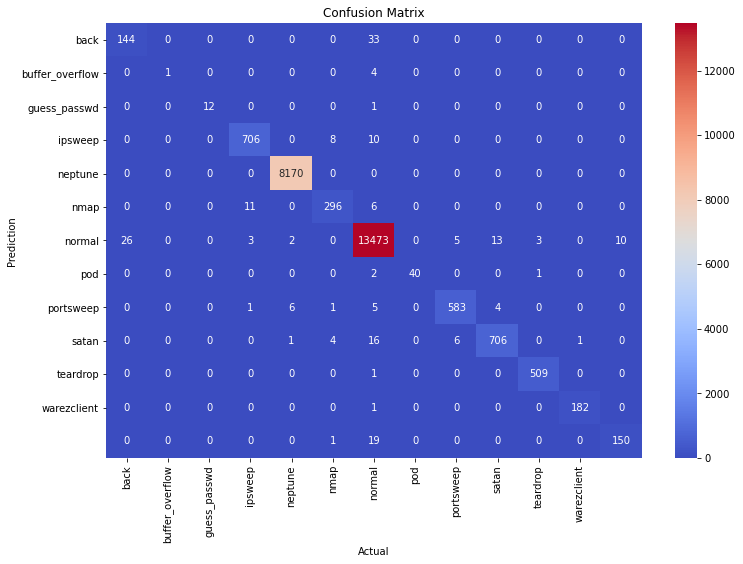

In [29]:
plt.figure(figsize=(12, 8))
# Confusion matrix 
cm = confusion_matrix(y_test,y_pred_test)

# Plotting the confusion matrix 
sns.heatmap(cm,
            cmap = 'coolwarm',
            annot=True,
            fmt = "g", 
            xticklabels=['back','buffer_overflow','guess_passwd','ipsweep','neptune','nmap','normal','pod','portsweep',
                         'satan','teardrop','warezclient'],
            yticklabels=['back','buffer_overflow','guess_passwd','ipsweep','neptune','nmap','normal','pod','portsweep',
                         'satan','teardrop','warezclient'])


plt.ylabel('Prediction')
plt.xlabel('Actual')
plt.title('Confusion Matrix')
plt.show()

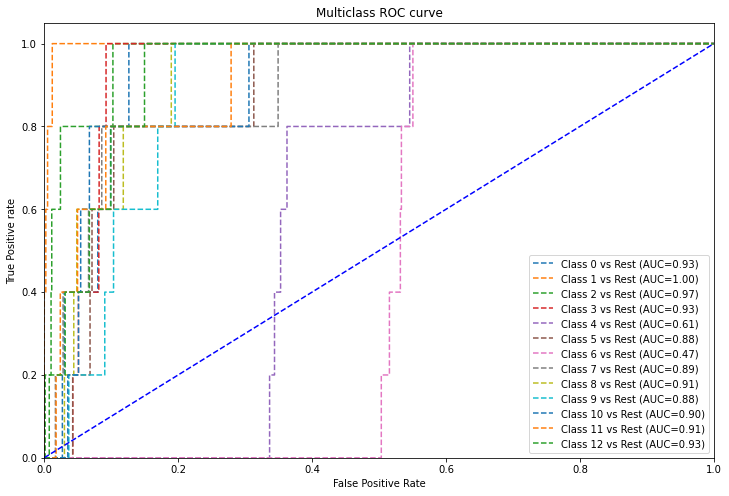

In [30]:
# roc curve for 13 classes

plt.figure(figsize=(12,8))
fpr = {}
tpr = {}
threshold ={}
n_class = 13
roc_auc = {}

for i in range(n_class): 
    fpr[i], tpr[i], threshold[i] = roc_curve(y_test, y_proba_test[:,i], pos_label = 1)
    roc_auc[i] = auc(fpr[i], tpr[i])
    # plotting    
    plt.plot(fpr[i], tpr[i], linestyle='--',label='Class {} vs Rest (AUC={:.2f})'.format(i, roc_auc[i]))

plt.plot([0,1],[0,1],'b--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='lower right')
plt.show()

****

In [31]:
# Predict the training time on train dataset
%time y_pred_train = best_gridcv.predict(X_train)

# printing the predictions
y_pred_train

Wall time: 3.13 s


array([6, 6, 6, ..., 4, 6, 6])

In [32]:
# Print the classification report for training dataset 
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       779
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        40
           3       0.99      1.00      1.00      2875
           4       1.00      1.00      1.00     33044
           5       1.00      0.99      0.99      1180
           6       1.00      1.00      1.00     53808
           7       1.00      1.00      1.00       158
           8       1.00      1.00      1.00      2331
           9       1.00      1.00      1.00      2899
          10       1.00      1.00      1.00      2136
          11       1.00      1.00      1.00       709
          12       1.00      1.00      1.00       720

    accuracy                           1.00    100704
   macro avg       1.00      1.00      1.00    100704
weighted avg       1.00      1.00      1.00    100704



In [33]:
def metrics(y_train, y_pred_train, y_test, y_pred_test):
    precision_train = precision_score(y_train, y_pred_train,average = 'macro')
    precision_test = precision_score(y_test, y_pred_test,average = 'macro')
    recall_train = recall_score(y_train, y_pred_train,average = 'macro')
    recall_test = recall_score(y_test, y_pred_test,average = 'macro')
    f1score_train = f1_score(y_train, y_pred_train,average = 'macro')
    f1score_test = f1_score(y_test, y_pred_test,average = 'macro')
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    metrics_dict = {
        "Precision (Train)": precision_train,
        "Precision (Test)": precision_test,
        "Recall (Train)": recall_train,
        "Recall (Test)": recall_test,
        "F1 Score (Train)": f1score_train,
        "F1 Score (Test)": f1score_test,
        "Accuracy (Train)": accuracy_train,
        "Accuracy (Test)": accuracy_test,
    }
    
    return metrics_dict

metrics(y_train, y_pred_train, y_test, y_pred_test)

{'Precision (Train)': 0.9992157050167154,
 'Precision (Test)': 0.9734598480916531,
 'Recall (Train)': 0.9990191424458845,
 'Recall (Test)': 0.8916584855989071,
 'F1 Score (Train)': 0.9991157235215142,
 'F1 Score (Test)': 0.9117317667504611,
 'Accuracy (Train)': 0.9997716078805211,
 'Accuracy (Test)': 0.9918576478531993}

In [34]:
def metrics(y_train, y_pred_train, y_test, y_pred_test):
    precision_train = precision_score(y_train, y_pred_train,average = 'weighted')
    precision_test = precision_score(y_test, y_pred_test,average = 'weighted')
    recall_train = recall_score(y_train, y_pred_train,average = 'weighted')
    recall_test = recall_score(y_test, y_pred_test,average = 'weighted')
    f1score_train = f1_score(y_train, y_pred_train,average = 'weighted')
    f1score_test = f1_score(y_test, y_pred_test,average = 'weighted')
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    metrics_dict = {
        "Precision (Train)": precision_train,
        "Precision (Test)": precision_test,
        "Recall (Train)": recall_train,
        "Recall (Test)": recall_test,
        "F1 Score (Train)": f1score_train,
        "F1 Score (Test)": f1score_test,
        "Accuracy (Train)": accuracy_train,
        "Accuracy (Test)": accuracy_test,
    }
    
    return metrics_dict

metrics(y_train, y_pred_train, y_test, y_pred_test)

{'Precision (Train)': 0.9997723198641079,
 'Precision (Test)': 0.9917794026396858,
 'Recall (Train)': 0.9997716078805211,
 'Recall (Test)': 0.9918576478531993,
 'F1 Score (Train)': 0.9997715880434783,
 'F1 Score (Test)': 0.9917507941915026,
 'Accuracy (Train)': 0.9997716078805211,
 'Accuracy (Test)': 0.9918576478531993}

****

In [35]:
# Checking for overfitting

%time print('Training set score: {:.4f}'.format(xgboost_gridcv.score(X_train, y_train)))

%time print('Test set score: {:.4f}'.format(xgboost_gridcv.score(X_test, y_test)))

Training set score: 0.9998
Wall time: 2.53 s
Test set score: 0.9919
Wall time: 623 ms


****

In [27]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Initialize dictionaries to store results for each class
detection_rates = {}
false_alarm_rates = {}
class_accuracies = {}
class_precision = {}
class_recall = {}
class_f1_score = {}
num_classes = 13

# Iterate over each class
for i in range(num_classes): 
    # Define the positive class as class i and the negative classes as all others
    positive_class = i
    negative_classes = [c for c in range(num_classes) if c != positive_class]

    # Calculate True Positives (TP), False Negatives (FN), False Positives (FP), and True Negatives (TN)
    TP = cm[i, i]
    FN = cm[i, negative_classes].sum()
    FP = cm[negative_classes, i].sum()
    TN = cm[negative_classes, negative_classes].sum()

    # Calculate Detection Rate (True Positive Rate) and False Alarm Rate for class i
    detection_rate = TP / (TP + FN)
    false_alarm_rate = FP / (FP + TN)
    
    # Calculate accuracy for class i
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    
    # Calculate precision
    precision = TP / (TP + FP)
    
    # Calculate recall
    recall = TP / (TP + FN)
    
    # calculate f1 score
    f1_score = 2 * (precision * recall) / (precision + recall)

    # Store the results in dictionaries
    detection_rates[f'Class_{i}'] = detection_rate
    false_alarm_rates[f'Class_{i}'] = false_alarm_rate
    class_accuracies[f'Class_{i}'] = accuracy
    class_precision[f'class_{i}'] = precision
    class_recall[f'class_{i}'] = recall
    class_f1_score[f'class{i}'] = f1_score

# Print the Detection Rates and False Alarm Rates for each class
for class_label, dr in detection_rates.items():
    print(f'Detection Rate for {class_label}: {dr:.4f}')

for class_label, far in false_alarm_rates.items():
    print(f'False Alarm Rate for {class_label}: {far:.4f}')

for class_label, acc in class_accuracies.items():
    print(f'Accuracy for {class_label}: {acc:.4f}')

for class_label, pre in class_precision.items():
    print(f'precision for {class_label}: {pre:.4f}')
    
for class_label, rec in class_recall.items():
    print(f'recall for {class_label}: {rec:.4f}')
    
for class_label, f1s in class_f1_score.items():
    print(f'f1_score for {class_label}: {f1s:.4f}')

Detection Rate for Class_0: 0.8136
Detection Rate for Class_1: 0.2000
Detection Rate for Class_2: 0.9231
Detection Rate for Class_3: 0.9751
Detection Rate for Class_4: 1.0000
Detection Rate for Class_5: 0.9457
Detection Rate for Class_6: 0.9954
Detection Rate for Class_7: 0.9302
Detection Rate for Class_8: 0.9717
Detection Rate for Class_9: 0.9619
Detection Rate for Class_10: 0.9980
Detection Rate for Class_11: 0.9945
Detection Rate for Class_12: 0.8824
False Alarm Rate for Class_0: 0.0010
False Alarm Rate for Class_1: 0.0000
False Alarm Rate for Class_2: 0.0000
False Alarm Rate for Class_3: 0.0006
False Alarm Rate for Class_4: 0.0005
False Alarm Rate for Class_5: 0.0006
False Alarm Rate for Class_6: 0.0085
False Alarm Rate for Class_7: 0.0000
False Alarm Rate for Class_8: 0.0005
False Alarm Rate for Class_9: 0.0007
False Alarm Rate for Class_10: 0.0002
False Alarm Rate for Class_11: 0.0000
False Alarm Rate for Class_12: 0.0004
Accuracy for Class_0: 0.9976
Accuracy for Class_1: 0.9998


***